In [3]:
import mlflow
import pandas as pd
from mlflow.tracking import MlflowClient
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
tracking_dir = "/home/pablo.sanchez2/Documents/GitHub/project_spaice_ds/packages/pip/kge/.ml_flow"
mlflow.set_tracking_uri(f"file:{tracking_dir}")

In [5]:
client = MlflowClient()

experiment = mlflow.get_experiment_by_name("pubtator_complex_hpo")
runs = client.search_runs(experiment_ids=[experiment.experiment_id])


df = pd.DataFrame(
    [r.data.metrics | r.data.params | {"run_id": r.info.run_id} for r in runs]
)
df = df.loc[:, df.nunique() > 1]
df = df.apply(pd.to_numeric, errors="ignore")  # convert strings → numbers

df.head()

/tmp/ipykernel_540770/843747020.py:11: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore")  # convert strings → numbers


,training/learning_rate,training/loss,validation/loss,optimizer.kwargs.weight_decay,optimizer.kwargs.lr,negative_sampler.config.num_negatives,loss_fn.config.margin,model_checkpoint.dirpath,model.config.embedding_dim,run.output_dir,lr_scheduler.kwargs.factor,run_id
0,0.001,120.0,120.0,0.000081,0.001,50,120.0,/home/pablo.sanchez2/Documents/GitHub/project_...,256,/home/pablo.sanchez2/Documents/GitHub/project_...,0.99,e5fee6c11bc64cf08fd15a5b41d45c8f
1,0.010,10.0,10.0,0.000038,0.010,50,10.0,/home/pablo.sanchez2/Documents/GitHub/project_...,128,/home/pablo.sanchez2/Documents/GitHub/project_...,0.50,cbb5a78f305b4de98c5ee57f801d80df
2,0.010,10.0,10.0,0.000037,0.010,20,10.0,/home/pablo.sanchez2/Documents/GitHub/project_...,128,/home/pablo.sanchez2/Documents/GitHub/project_...,0.50,ded6aec6151d4f8fbbaae849a46317be
3,0.010,10.0,10.0,0.000029,0.010,20,10.0,/home/pablo.sanchez2/Documents/GitHub/project_...,512,/home/pablo.sanchez2/Documents/GitHub/project_...,0.50,ff5f599388534675b87dcd362b2d75ce
4,0.010,120.0,120.0,0.000031,0.010,20,120.0,/home/pablo.sanchez2/Documents/GitHub/project_...,256,/home/pablo.sanchez2/Documents/GitHub/project_...,0.99,d3c1fed052b7470e88948d2fe43a67ff


In [6]:
for c in sorted(df.columns):
    print(c)

loss_fn.config.margin
lr_scheduler.kwargs.factor
model.config.embedding_dim
model_checkpoint.dirpath
negative_sampler.config.num_negatives
optimizer.kwargs.lr
optimizer.kwargs.weight_decay
run.output_dir
run_id
training/learning_rate
training/loss
validation/loss


In [7]:
hyperparams_prefixes = ["model.config", "loss_fn.config", "lr_scheduler", "negative_sampler", "optimizer"] 

hyperparams = [c for c in df.columns if any(c.startswith(prefix) for prefix in hyperparams_prefixes)]

for hp in hyperparams:
    print(hp)


optimizer.kwargs.weight_decay
optimizer.kwargs.lr
negative_sampler.config.num_negatives
loss_fn.config.margin
model.config.embedding_dim
lr_scheduler.kwargs.factor


In [8]:
from sklearn.ensemble import RandomForestRegressor

def compute_importance(df: pd.DataFrame):
    X = df[hyperparams].apply(pd.to_numeric, errors="coerce").fillna(0)
    y = df["validation/loss"]

    model = RandomForestRegressor()
    model.fit(X, y)

    importance = pd.Series(model.feature_importances_, index=hyperparams)
    print(importance.sort_values(ascending=False))


In [9]:
df["loss_fn.config.margin"].unique()

array([120.,  10.,   1.,  50.])

In [11]:
for margin in df["loss_fn.config.margin"].unique():
    cond = df["loss_fn.config.margin"] == margin
    df_i = df[cond]
    print(f"Num runs {len(df_i)}")
    compute_importance(df_i)
    print("-----------")

Num runs 26
optimizer.kwargs.weight_decay            0.754557
optimizer.kwargs.lr                      0.227378
negative_sampler.config.num_negatives    0.009134
lr_scheduler.kwargs.factor               0.008931
loss_fn.config.margin                    0.000000
model.config.embedding_dim               0.000000
dtype: float64
-----------
Num runs 41
optimizer.kwargs.lr                      0.830593
optimizer.kwargs.weight_decay            0.109494
lr_scheduler.kwargs.factor               0.034124
model.config.embedding_dim               0.015388
negative_sampler.config.num_negatives    0.010400
loss_fn.config.margin                    0.000000
dtype: float64
-----------
Num runs 12


optimizer.kwargs.lr                      0.908500
optimizer.kwargs.weight_decay            0.042885
negative_sampler.config.num_negatives    0.022736
lr_scheduler.kwargs.factor               0.022124
model.config.embedding_dim               0.003755
loss_fn.config.margin                    0.000000
dtype: float64
-----------
Num runs 21
optimizer.kwargs.weight_decay            0.681663
optimizer.kwargs.lr                      0.178201
lr_scheduler.kwargs.factor               0.069739
negative_sampler.config.num_negatives    0.058510
model.config.embedding_dim               0.011886
loss_fn.config.margin                    0.000000
dtype: float64
-----------


x: optimizer.kwargs.weight_decay
y: validation/loss
hue: model.config.embedding_dim


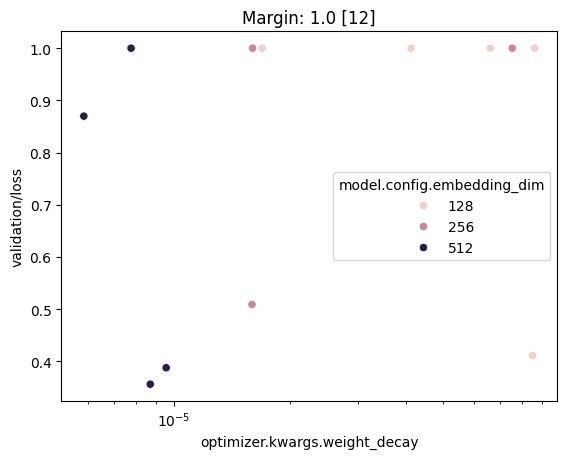

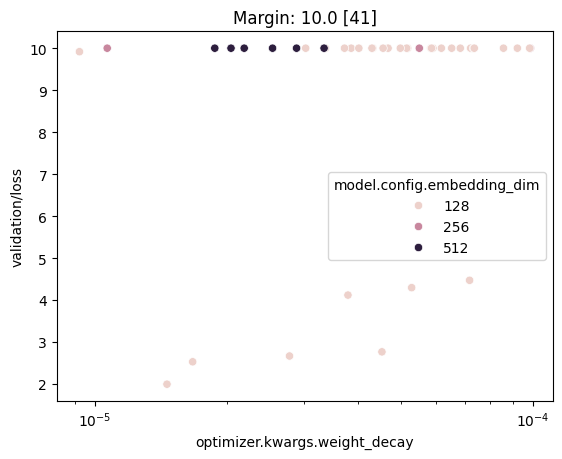

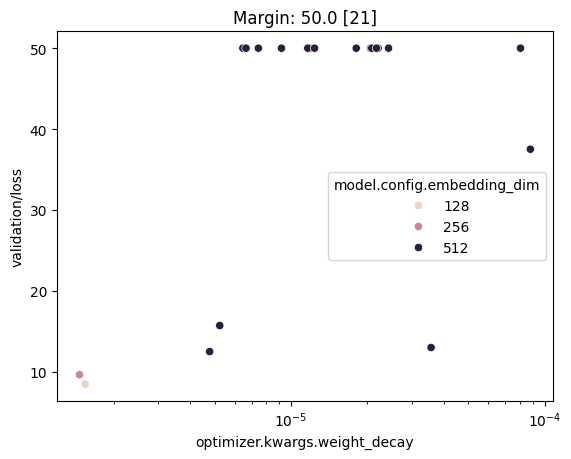

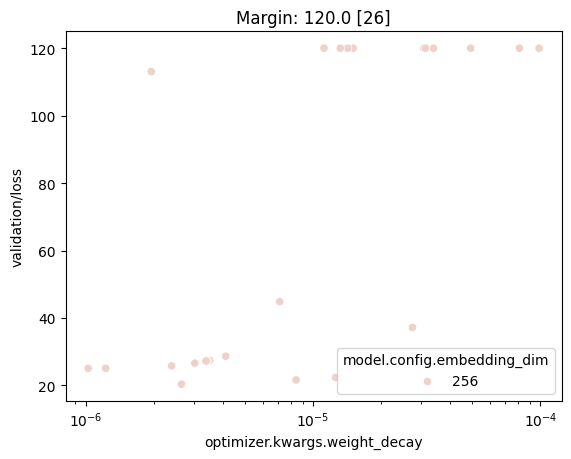

In [26]:


# hue="negative_sampler.config.num_negatives"
# hue="loss_fn.config.margin"
hue = "validation/loss"
scatter_config = {
    "validation/loss": "y",
    "negative_sampler.config.num_negatives": None,
    "model.config.embedding_dim": "hue",
    "lr_scheduler.kwargs.factor": None,
    "optimizer.kwargs.weight_decay": "x",
    "optimizer.kwargs.lr": None,
}

hue, x, y = None, None, None
for key, value in scatter_config.items():
    if value == "hue":
        hue = key
    if value == "x":
        x = key
    if value == "y":
        y = key

print(f"x: {x}")
print(f"y: {y}")
print(f"hue: {hue}")
for margin, df_i in df.groupby("loss_fn.config.margin"):
    plt.figure()
    sns.scatterplot(data=df_i, 
                    y=y,
                    x=x,
                    hue=hue)
    plt.xscale('log')
    plt.title(f"Margin: {margin} [{len(df_i)}]")



In [13]:
best_config = df.sort_values("validation/loss").iloc[0]

best_config[hyperparams]

optimizer.kwargs.weight_decay            0.000009
optimizer.kwargs.lr                           0.1
negative_sampler.config.num_negatives          50
loss_fn.config.margin                         1.0
model.config.embedding_dim                    512
lr_scheduler.kwargs.factor                    0.1
Name: 97, dtype: object

In [45]:
group_by_cols = [
    "negative_sampler.config.num_negatives",
    "loss_fn.config.margin"
]
agg_funcs = ["mean", "std", "median"]

result: pd.DataFrame = (
    df.groupby(group_by_cols)
      .agg({col: agg_funcs for col in df.select_dtypes(include="number").columns 
            if col not in group_by_cols})
)

# Optional: flatten MultiIndex columns
result.columns = ["_".join(col).strip() for col in result.columns.values]
result = result.sort_values("validation/loss_median")

result[["validation/loss_mean", "training/loss_mean", "training/learning_rate_mean"]].reset_index()


,negative_sampler.config.num_negatives,loss_fn.config.margin,validation/loss_mean,training/loss_mean,training/learning_rate_mean
0,100,1.0,0.699651,0.677282,0.050500
1,20,1.0,0.754405,0.727665,0.250500
2,50,1.0,0.871001,0.861477,0.017200
3,50,10.0,8.598593,8.502696,0.065939
4,100,10.0,10.000000,10.000000,0.001000
5,20,10.0,9.272305,9.214412,0.005827
6,50,50.0,25.165514,23.716648,0.034000
7,100,120.0,56.765675,52.515553,0.028116
8,20,50.0,35.071925,33.923881,0.022420
9,100,50.0,45.844671,44.609343,0.039800


In [52]:
cols = [ "validation/loss", "training/learning_rate", "negative_sampler.config.num_negatives"] 
for c, df_i in df.groupby("loss_fn.config.margin"):
    print(c)
    corr = df_i[cols].corr()
    print(corr)
    print("")


1.0
                                       validation/loss  \
validation/loss                               1.000000   
training/learning_rate                       -0.590555   
negative_sampler.config.num_negatives        -0.174292   

                                       training/learning_rate  \
validation/loss                                     -0.590555   
training/learning_rate                               1.000000   
negative_sampler.config.num_negatives               -0.299175   

                                       negative_sampler.config.num_negatives  
validation/loss                                                    -0.174292  
training/learning_rate                                             -0.299175  
negative_sampler.config.num_negatives                               1.000000  

10.0
                                       validation/loss  \
validation/loss                               1.000000   
training/learning_rate                       -0.632936   
negati

In [48]:
df_i

NameError: name 'df_i' is not defined